In [1]:
import pickle
import os
from pathlib import Path
from msd_with_com import fit_diffusion, a2ps_to_m2s
from matplotlib import pyplot as plt
import numpy as np

In [3]:
def fit_diffusion_wrapper(tau, msd_cat, msd_anion, msd_solvent, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS):
    Dcat_a2ps, slope_c, b_c, mask_c = fit_diffusion(tau, msd_cat, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS)
    Dcat_1e10 = a2ps_to_m2s(Dcat_a2ps) * 1e10
    # print(f"   → D(Na⁺) = {Dcat_1e10:.2f} ×10⁻¹⁰ m²/s ({Dcat_a2ps:.4f} Å²/ps)")


    Danion_a2ps, slope_a, b_a, mask_a = fit_diffusion(tau, msd_anion, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS)
    Danion_1e10 = a2ps_to_m2s(Danion_a2ps) * 1e10
    # print(f"   → D(anion) = {Danion_1e10:.2f} ×10⁻¹⁰ m²/s ({Danion_a2ps:.4f} Å²/ps)")


    Dsolv_a2ps, slope_s, b_s, mask_s = fit_diffusion(tau, msd_solvent, TAU_MIN_FIT_PS, TAU_MAX_FIT_PS)
    Dsolv_1e10 = a2ps_to_m2s(Dsolv_a2ps) * 1e10
    # print(f"   → D(solvent) = {Dsolv_1e10:.2f} ×10⁻¹⁰ m²/s ({Dsolv_a2ps:.4f} Å²/ps)")

    return Dcat_1e10, Danion_1e10, Dsolv_1e10, Dcat_a2ps, Danion_a2ps, Dsolv_a2ps

In [13]:
msd_dict_path = Path("/global/homes/y/yuejian/project/MLFF-distill/yuejian/electrolyte_application/ablate_distillation/observables/msd/nvt_unstable/7ns/msd_dict_NaPF6 - DME_323K_0_5M.pkl")
base_name = os.path.basename(msd_dict_path).strip(".pkl")
# Load the msd_dict files using pickle
with open(msd_dict_path, "rb") as f:
    msd_dict_naotf = pickle.load(f)

# You can now inspect msd_dicts, for example:
# print("NaOTf — DME dict keys:", msd_dict_naotf.keys())

# Unpack variables from msd_dict_naotf
tau_naotf         = msd_dict_naotf["tau"]
msd_cat_naotf     = msd_dict_naotf["msd_cat"]
msd_anion_naotf   = msd_dict_naotf["msd_anion"]
msd_solvent_naotf = msd_dict_naotf["msd_solvent"]
dt_ps_naotf       = msd_dict_naotf["dt_ps"]
eq_time_ps_naotf  = msd_dict_naotf["EQ_TIME_PS"]

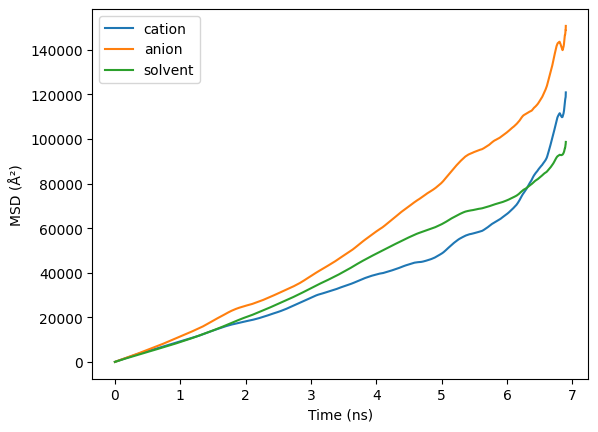

In [14]:
# msd - tau
tau_naotf_ns = tau_naotf / 1000
plt.plot(tau_naotf_ns, msd_cat_naotf,label="cation")
plt.plot(tau_naotf_ns, msd_anion_naotf,label="anion")
plt.plot(tau_naotf_ns, msd_solvent_naotf,label="solvent")
plt.xlabel("Time (ns)")
plt.ylabel("MSD (Å²)")
plt.legend()
plt.show()

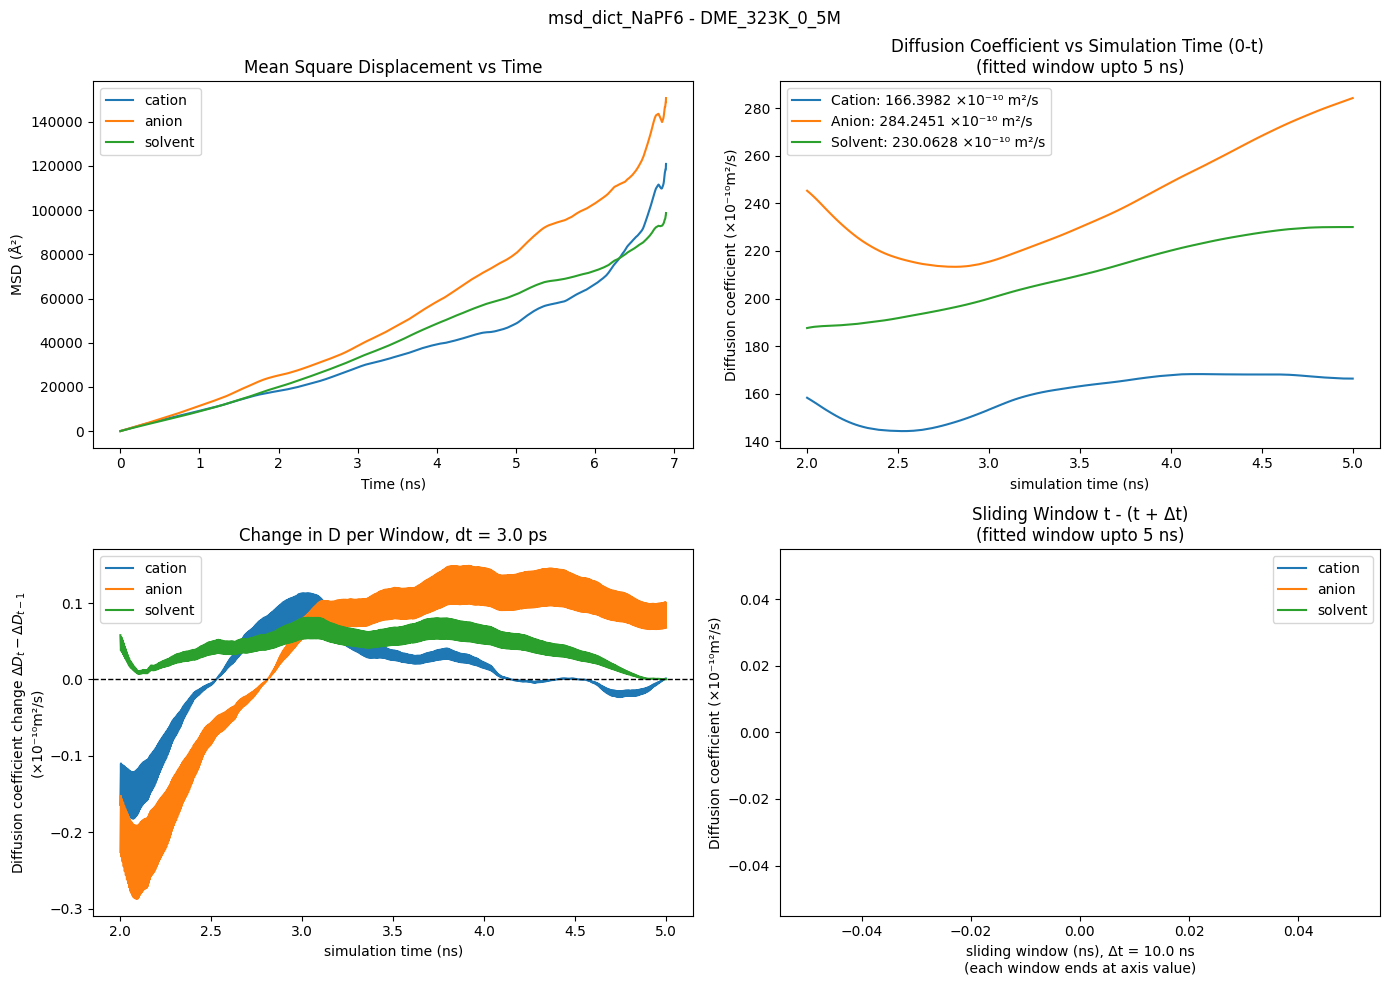

In [15]:
fit_window_upto_ns = 5

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

# --- 1. msd - tau ---
tau_naotf_ns = tau_naotf / 1000
axs[0].plot(tau_naotf_ns, msd_cat_naotf,label="cation")
axs[0].plot(tau_naotf_ns, msd_anion_naotf,label="anion")
axs[0].plot(tau_naotf_ns, msd_solvent_naotf,label="solvent")
axs[0].set_xlabel("Time (ns)")
axs[0].set_ylabel("MSD (Å²)")
axs[0].legend()
axs[0].set_title("Mean Square Displacement vs Time")

# --- 2. Diffusion coefficient vs fitting window (end) ---
min_fit_ps = 1000
start = 2000
end = int(fit_window_upto_ns*1000)
dt = (end - start) / 1000 # ps
number_of_points = 1000
max_fit_ps_list = np.linspace(start,end,number_of_points)
D_cations, D_anions, D_solvent = [], [], []
for max_fit_ps in max_fit_ps_list:
    Dcat_1e10, Danion_1e10, Dsolv_1e10, _, _, _ = fit_diffusion_wrapper(
        tau_naotf, msd_cat_naotf, msd_anion_naotf, msd_solvent_naotf, min_fit_ps, max_fit_ps
    )
    D_cations.append(Dcat_1e10)
    D_anions.append(Danion_1e10)
    D_solvent.append(Dsolv_1e10)

max_fit_ps_list_ns = max_fit_ps_list / 1000
axs[1].plot(max_fit_ps_list_ns, D_cations,label=f"Cation: {D_cations[-1]:.4f} ×10⁻¹⁰ m²/s")
axs[1].plot(max_fit_ps_list_ns, D_anions,label=f"Anion: {D_anions[-1]:.4f} ×10⁻¹⁰ m²/s")
axs[1].plot(max_fit_ps_list_ns, D_solvent,label=f"Solvent: {D_solvent[-1]:.4f} ×10⁻¹⁰ m²/s")
axs[1].legend()
axs[1].set_xlabel("simulation time (ns)")
axs[1].set_ylabel("Diffusion coefficient (×10⁻¹⁰m²/s)")
axs[1].set_title(f"Diffusion Coefficient vs Simulation Time (0-t) \n(fitted window upto {fit_window_upto_ns} ns)")

# --- 3. Delta D vs fitting window (difference in D per window) ---
delta_D_cations = np.array(D_cations+[0]) - np.array([0]+D_cations)
delta_D_anions = np.array(D_anions+[0]) - np.array([0]+D_anions)
delta_D_solvent = np.array(D_solvent+[0]) - np.array([0]+D_solvent)
axs[2].plot(max_fit_ps_list_ns[1:], delta_D_cations[1:-1],label="cation")
axs[2].plot(max_fit_ps_list_ns[1:], delta_D_anions[1:-1],label="anion")
axs[2].plot(max_fit_ps_list_ns[1:], delta_D_solvent[1:-1],label="solvent")
axs[2].axhline(0, color="black", linestyle="--", linewidth=1, label='_nolegend_')
axs[2].legend()
axs[2].set_xlabel("simulation time (ns)")
axs[2].set_ylabel("Diffusion coefficient change $\Delta D_{t} - \Delta D_{t-1}$\n(×10⁻¹⁰m²/s)")
axs[2].set_title(f"Change in D per Window, dt = {dt} ps")

# --- 4. Sliding window D vs window end ---
window_size = 10000 # ps
original_start_ps = 0
start_ps = original_start_ps
end_ps = start_ps + window_size
max_ps = int(fit_window_upto_ns*1000)
fit_windows = []
end_ps_list = []
while end_ps < max_ps:
    fit_windows.append((start_ps, end_ps))
    end_ps_list.append(end_ps)
    start_ps = start_ps + 10 #ps
    end_ps = start_ps + window_size

D_cations_slide = []
D_anions_slide = []
D_solvent_slide = []
for min_fit_ps, max_fit_ps in fit_windows:
    Dcat_1e10, Danion_1e10, Dsolv_1e10, _, _, _ = fit_diffusion_wrapper(
        tau_naotf, msd_cat_naotf, msd_anion_naotf, msd_solvent_naotf, min_fit_ps, max_fit_ps
    )
    D_cations_slide.append(Dcat_1e10)
    D_anions_slide.append(Danion_1e10)
    D_solvent_slide.append(Dsolv_1e10)

end_ps_list_ns = np.array(end_ps_list) / 1000

axs[3].plot(end_ps_list_ns, D_cations_slide,label="cation")
axs[3].plot(end_ps_list_ns, D_anions_slide,label="anion")
axs[3].plot(end_ps_list_ns, D_solvent_slide,label="solvent")
axs[3].legend()
axs[3].set_xlabel(f"sliding window (ns), Δt = {window_size/1000} ns\n(each window ends at axis value)")
axs[3].set_ylabel("Diffusion coefficient (×10⁻¹⁰m²/s)")
axs[3].set_title(f"Sliding Window t - (t + Δt)\n(fitted window upto {fit_window_upto_ns} ns)")

fig.suptitle(base_name)
plt.tight_layout()
plt.show()

In [390]:
# fit_window_upto_ns = 18
# min_fit_ps = 0
# max_fit_ps_list = np.linspace(2000,int(fit_window_upto_ns*1000),1000)
# # naotf
# D_cations = []
# D_anions = []
# D_solvent = []

# for max_fit_ps in max_fit_ps_list:
#     Dcat_1e10, Danion_1e10, Dsolv_1e10, Dcat_a2ps, Danion_a2ps, Dsolv_a2ps = fit_diffusion_wrapper(tau_naotf, msd_cat_naotf, msd_anion_naotf, msd_solvent_naotf, min_fit_ps, max_fit_ps)
#     D_cations.append(Dcat_1e10)
#     D_anions.append(Danion_1e10)
#     D_solvent.append(Dsolv_1e10)

# max_fit_ps_list_ns = max_fit_ps_list / 1000

# plt.plot(max_fit_ps_list_ns, D_cations,label=f"Cation: {D_cations[-1]:.4f} ×10⁻¹⁰ m²/s")
# plt.plot(max_fit_ps_list_ns, D_anions,label=f"Anion: {D_anions[-1]:.4f} ×10⁻¹⁰ m²/s")
# plt.plot(max_fit_ps_list_ns, D_solvent,label=f"Solvent: {D_solvent[-1]:.4f} ×10⁻¹⁰ m²/s")
# plt.legend()
# plt.xlabel("simulation time (ns)")
# plt.ylabel("Diffusion coefficient (×10⁻¹⁰m²/s)")
# plt.title(f"fitted window upto {fit_window_upto_ns} ns")
# plt.show()

In [391]:
# 2000,int(fit_window_upto_ns*1000),1000

# dt = (int(fit_window_upto_ns*1000) - 2000) / 1000 # ps
# print(dt)
# delta_D_cations = np.array(D_cations+[0]) - np.array([0]+D_cations)
# delta_D_anions = np.array(D_anions+[0]) - np.array([0]+D_anions)
# delta_D_solvent = np.array(D_solvent+[0]) - np.array([0]+D_solvent)

# print(delta_D_solvent[1:-1])
# print(D_solvent)
# plt.plot(max_fit_ps_list_ns[1:], delta_D_cations[1:-1],label="cation")
# plt.plot(max_fit_ps_list_ns[1:], delta_D_anions[1:-1],label="anion")
# plt.plot(max_fit_ps_list_ns[1:], delta_D_solvent[1:-1],label="solvent")
# plt.axhline(0, color="black", linestyle="--", linewidth=1, label='_nolegend_')
# plt.legend()
# plt.xlabel("simulation time (ns)")
# plt.ylabel("Diffusion coefficient change $\Delta D_{t} - \Delta D_{t-1}$ (×10⁻¹⁰m²/s)")
# plt.title(f"fitted window upto {fit_window_upto_ns} ns, dt = {dt} ps")
# plt.show()


In [392]:
# window_size = 10000 # ps
# original_start_ps = 0
# start_ps = original_start_ps

# end_ps = start_ps + window_size
# max_ps = int(fit_window_upto_ns*1000)
# fit_windows = []
# end_ps_list = []
# while end_ps < max_ps:
#     fit_windows.append((start_ps, end_ps))
#     end_ps_list.append(end_ps)
#     start_ps = start_ps + 10 #ps
#     end_ps = start_ps + window_size

# # naotf
# D_cations = []
# D_anions = []
# D_solvent = []

# for min_fit_ps, max_fit_ps in fit_windows:
#     Dcat_1e10, Danion_1e10, Dsolv_1e10, Dcat_a2ps, Danion_a2ps, Dsolv_a2ps = fit_diffusion_wrapper(tau_naotf, msd_cat_naotf, msd_anion_naotf, msd_solvent_naotf, min_fit_ps, max_fit_ps)
#     D_cations.append(Dcat_1e10)
#     D_anions.append(Danion_1e10)
#     D_solvent.append(Dsolv_1e10)

# end_ps_list_ns = np.array(end_ps_list) / 1000

# plt.plot(end_ps_list_ns, D_cations,label="cation")
# plt.plot(end_ps_list_ns, D_anions,label="anion")
# plt.plot(end_ps_list_ns, D_solvent,label="solvent")
# plt.legend()
# plt.xlabel(f"sliding window (ns) delta t = {window_size/1000} ns, each window end at time on axis")
# plt.ylabel("Diffusion coefficient (×10⁻¹⁰m²/s)")
# plt.title(f"fitted window upto {fit_window_upto_ns} ns")
# plt.show()